<a href="https://colab.research.google.com/github/rishiwalia08/Attention-Enhanced-Few-Shot-CNN-Autoencoder-for-Anomaly-Detection-DL-ASSIGNMENT-/blob/main/attention_autoencoder_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Attention-Enhanced Few-Shot CNN Autoencoder for Anomaly Detection

## Objective
This project proposes an attention-enhanced CNN autoencoder for anomaly detection under few-shot learning conditions.

### Key Features:
- CNN Autoencoder
- Attention Mechanism
- Few-shot learning setup
- Reconstruction-based anomaly detection


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

## Dataset (CIFAR-10 as Example)

In [2]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

subset = torch.utils.data.Subset(dataset, range(2000))
dataloader = DataLoader(subset, batch_size=32, shuffle=True)

100%|██████████| 170M/170M [00:03<00:00, 47.8MB/s]


## Model Architecture

In [3]:
class AttentionBlock(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, in_channels, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        attn = self.sigmoid(self.conv(x))
        return x * attn

class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU()
        )

        self.attn = AttentionBlock(64)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.attn(x)
        x = self.decoder(x)
        return x

model = Autoencoder()
print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
  )
  (attn): AttentionBlock(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
    (sigmoid): Sigmoid()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 3, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): Sigmoid()
  )
)


## Training

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 5

for epoch in range(epochs):
    for imgs, _ in dataloader:
        imgs = imgs.to(device)

        outputs = model(imgs)
        loss = criterion(outputs, imgs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.0143
Epoch 2, Loss: 0.0115
Epoch 3, Loss: 0.0059
Epoch 4, Loss: 0.0060
Epoch 5, Loss: 0.0066


## Evaluation & Visualization

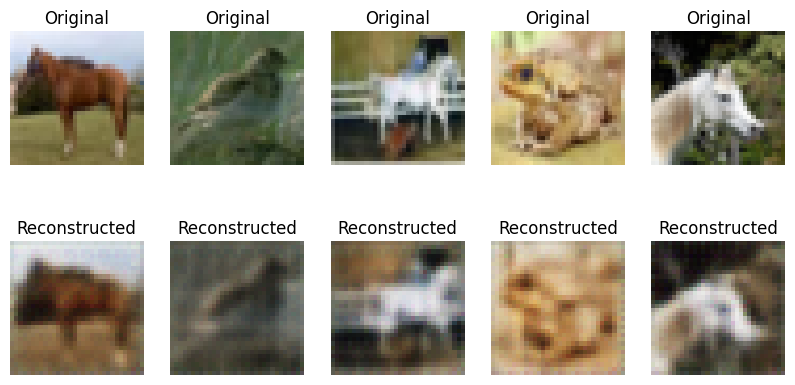

In [5]:
imgs, _ = next(iter(dataloader))
imgs = imgs.to(device)

with torch.no_grad():
    outputs = model(imgs)

imgs = imgs.cpu()
outputs = outputs.cpu()

fig, axs = plt.subplots(2, 5, figsize=(10,5))

for i in range(5):
    axs[0, i].imshow(imgs[i].permute(1,2,0))
    axs[0, i].set_title("Original")
    axs[0, i].axis('off')

    axs[1, i].imshow(outputs[i].permute(1,2,0))
    axs[1, i].set_title("Reconstructed")
    axs[1, i].axis('off')

plt.show()

## Anomaly Heatmap

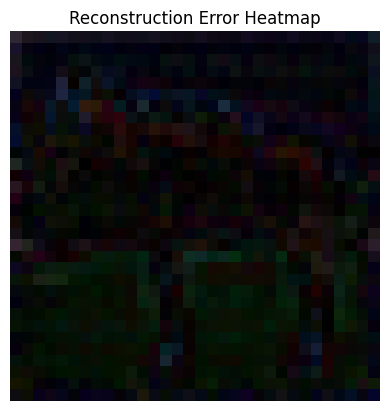

In [6]:
error = torch.abs(imgs - outputs)

plt.imshow(error[0].permute(1,2,0))
plt.title("Reconstruction Error Heatmap")
plt.axis('off')
plt.show()

## Conclusion
The attention-enhanced autoencoder improves anomaly detection by focusing on important regions.
Few-shot learning setup makes it practical for real-world applications where data is limited.
